Fetching UEFA Euro 2024 Match Schedule...
Found 51 matches in Euro 2024.
  ...processed 10/51 matches
  ...processed 20/51 matches
  ...processed 30/51 matches
  ...processed 40/51 matches
  ...processed 50/51 matches

Extracted 76199 total spatial transitions from Euro 2024 (excluding goal kicks)!

--- ACTUAL EURO 2024 GOAL PROBABILITIES BY STARTING ZONE ---
Start in Z1: 1.54% chance of a Goal
Start in Z2: 2.84% chance of a Goal
Start in Z3: 1.60% chance of a Goal
Start in Z4: 1.36% chance of a Goal
Start in Z5: 1.45% chance of a Goal
Start in Z6: 1.38% chance of a Goal
Start in Z7: 1.37% chance of a Goal
Start in Z8: 1.45% chance of a Goal
Start in Z9: 1.36% chance of a Goal
Start in Z10: 1.66% chance of a Goal
Start in Z11: 2.43% chance of a Goal
Start in Z12: 1.62% chance of a Goal


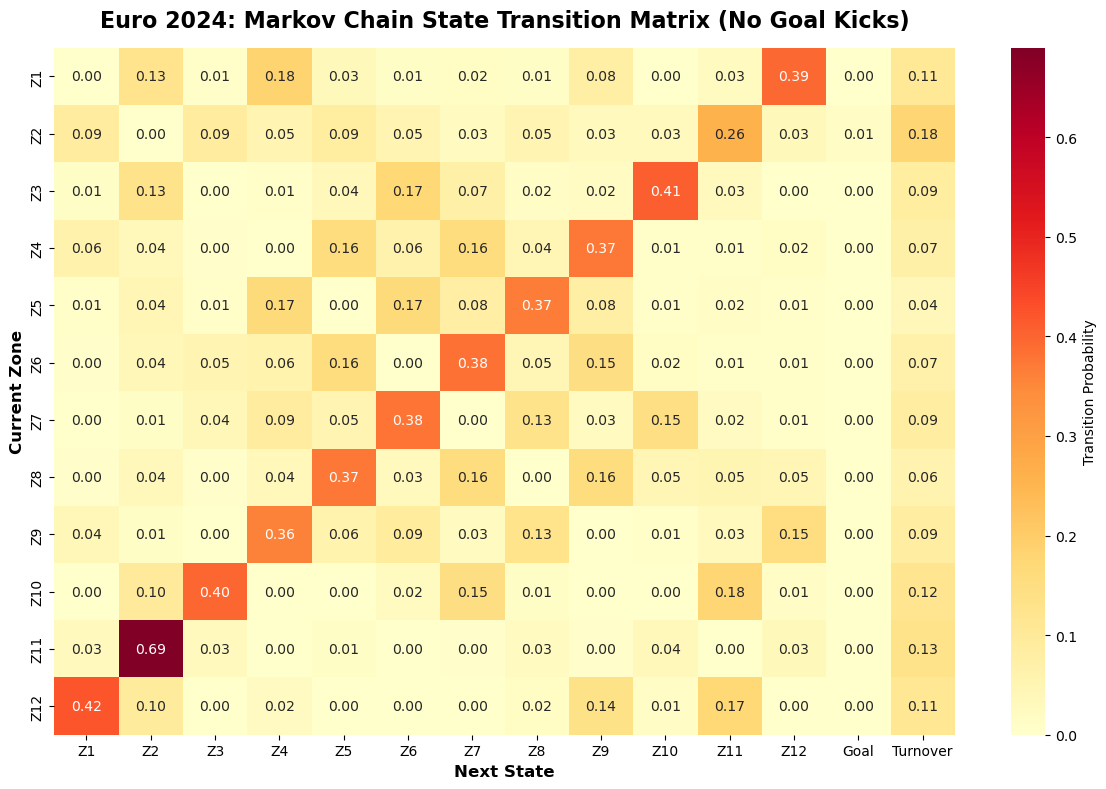

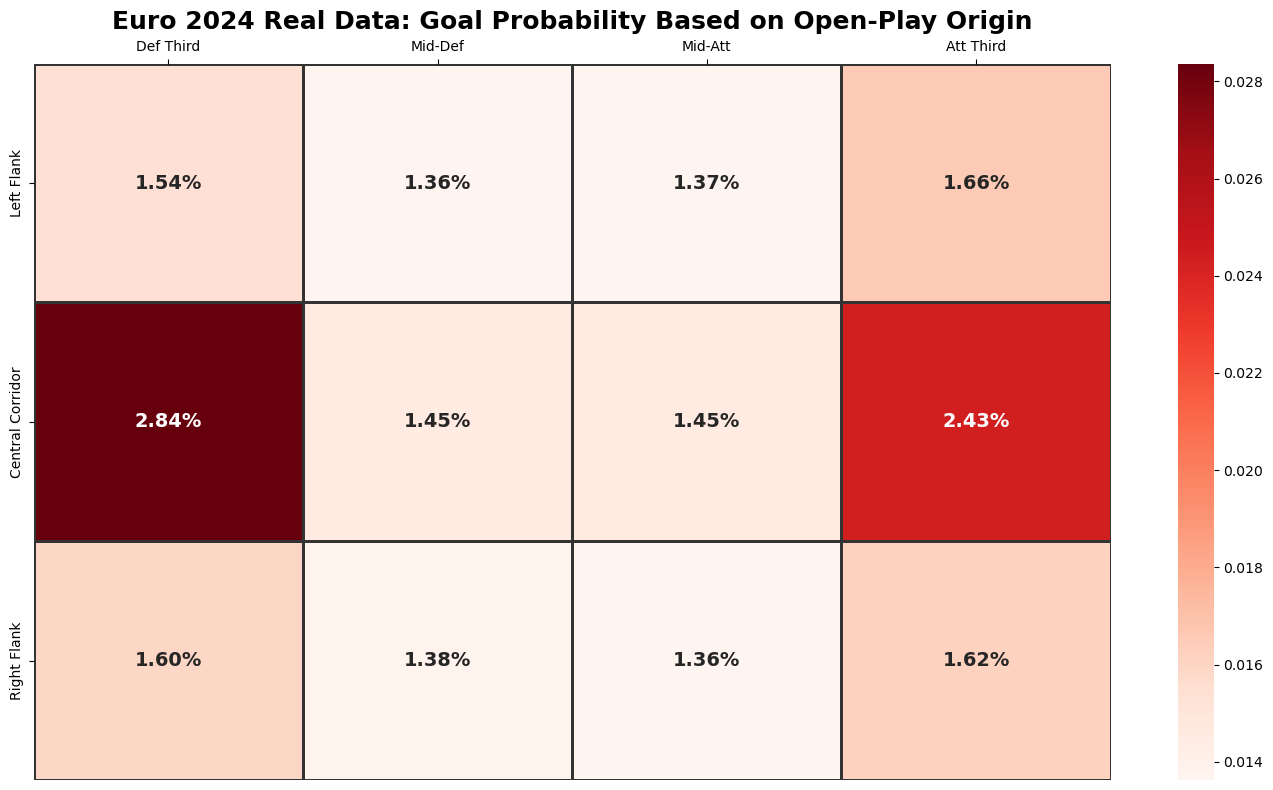

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

# Disable requests_cache if it's monkey-patching requests
try:
    import requests_cache
    requests_cache.uninstall_cache()
except ImportError:
    pass

session = requests.Session()

# =====================================================================
# 1. FETCH ACTUAL EURO 2024 MATCHES FROM STATSBOMB
# =====================================================================
print("Fetching UEFA Euro 2024 Match Schedule...")

# Euro 2024: Competition ID 55, Season ID 282
matches_url = "https://raw.githubusercontent.com/statsbomb/open-data/master/data/matches/55/282.json"
matches_data = session.get(matches_url).json()

match_ids = [m['match_id'] for m in matches_data]
print(f"Found {len(match_ids)} matches in Euro 2024.")

# =====================================================================
# 2. EXTRACT POSSESSION CHAINS AND MAP TO ZONES
# =====================================================================
# Helper function to convert StatsBomb's 120x80 pitch into our 12 Zones
def get_zone(x, y):
    col = min(int(x // 30), 3)  # 0 to 3 (Def, Mid-Def, Mid-Att, Att)
    row = min(int(y // 26.66), 2) # 0 to 2 (Left, Central, Right)
    
    zone_matrix = [
        ['Z1', 'Z4', 'Z7', 'Z10'], # Left Flank
        ['Z2', 'Z5', 'Z8', 'Z11'], # Central Corridor
        ['Z3', 'Z6', 'Z9', 'Z12']  # Right Flank
    ]
    return zone_matrix[row][col]

transitions = []

print("Downloading and processing event data for all matches (This takes ~60 seconds)...")
for idx, m_id in enumerate(match_ids):
    if (idx + 1) % 10 == 0:
        print(f"  ...processed {idx + 1}/{len(match_ids)} matches")
        
    events_url = f"https://raw.githubusercontent.com/statsbomb/open-data/master/data/events/{m_id}.json"
    events = session.get(events_url).json()
    
    # Group events by their unique possession ID
    possessions = {}
    for event in events:
        poss_id = event.get('possession')
        if not poss_id: continue
        if poss_id not in possessions:
            possessions[poss_id] = []
        possessions[poss_id].append(event)
        
    # Analyze the spatial path of every single possession
    for poss_id, poss_events in possessions.items():
        # Ensure events are in chronological order
        poss_events = sorted(poss_events, key=lambda e: e.get('index', 0))
        
        # -------------------------------------------------------------
        # NEW FILTER: EXCLUDE GOAL KICKS
        # -------------------------------------------------------------
        # Check if the possession starts from a goal kick
        is_goal_kick = False
        for event in poss_events:
            play_pattern = event.get('play_pattern', {}).get('name')
            pass_type = event.get('pass', {}).get('type', {}).get('name')
            
            # If the play pattern is a Goal Kick, or the pass is explicitly a Goal Kick
            if play_pattern == 'From Goal Kick' or pass_type == 'Goal Kick':
                is_goal_kick = True
                break
                
        if is_goal_kick:
            continue  # Skip this entire possession sequence
        # -------------------------------------------------------------
        
        current_zone = None
        poss_path = []
        is_goal = False
        
        for event in poss_events:
            # Did this possession result in a goal?
            if event['type']['name'] == 'Shot':
                if event.get('shot', {}).get('outcome', {}).get('name') == 'Goal':
                    is_goal = True
            
            # Map the event's location
            loc = event.get('location')
            if isinstance(loc, list) and len(loc) == 2:
                zone = get_zone(loc[0], loc[1])
                
                # Only record a transition if the ball actually changes zones
                if current_zone is None:
                    current_zone = zone
                    poss_path.append(zone)
                elif zone != current_zone:
                    poss_path.append(zone)
                    current_zone = zone
                    
        # Skip empty or single-event sequences
        if not poss_path: continue
        
        # The ultimate fate of the possession
        absorbing_state = 'Goal' if is_goal else 'Turnover'
        
        # Log all the transitions for the Markov matrix
        for i in range(len(poss_path) - 1):
            transitions.append({'from_state': poss_path[i], 'to_state': poss_path[i+1]})
        transitions.append({'from_state': poss_path[-1], 'to_state': absorbing_state})

df = pd.DataFrame(transitions)
print(f"\nExtracted {len(df)} total spatial transitions from Euro 2024 (excluding goal kicks)!")

# =====================================================================
# 3. SOLVE MARKOV CHAIN METRIC (ABSORBING PROBABILITIES)
# =====================================================================
zones = [f"Z{i}" for i in range(1, 13)]
states = zones + ['Goal', 'Turnover']

transition_counts = pd.crosstab(df['from_state'], df['to_state'])

# Ensure all states exist in the matrix dimensions
for s in states:
    if s not in transition_counts.index:
        transition_counts.loc[s] = 0
    if s not in transition_counts.columns:
        transition_counts[s] = 0

ordered_states = zones + ['Goal', 'Turnover']
P_raw = transition_counts.loc[ordered_states, ordered_states]

# Make absorbing states self-looping
P_raw.loc['Goal', 'Goal'] = 1
P_raw.loc['Turnover', 'Turnover'] = 1

# Row-normalize to convert raw counts to probabilities
P = P_raw.div(P_raw.sum(axis=1), axis=0).fillna(0).values

n_transient = len(zones)
Q = P[:n_transient, :n_transient]
R = P[:n_transient, n_transient:]

# Calculate Fundamental Matrix and Absorbing Probabilities
I = np.eye(n_transient)
N = np.linalg.inv(I - Q)
B = np.dot(N, R)

goal_probabilities = B[:, 0]
zone_goal_map = dict(zip(zones, goal_probabilities))

print("\n--- ACTUAL EURO 2024 GOAL PROBABILITIES BY STARTING ZONE ---")
for zone, prob in zone_goal_map.items():
    print(f"Start in {zone}: {prob*100:.2f}% chance of a Goal")

# =====================================================================
# 4. PLOT GRAPH 1: TRANSITION PROBABILITY HEATMAP
# =====================================================================
plt.figure(figsize=(12, 8), facecolor='white')
sns.heatmap(
    P[:n_transient, :], 
    annot=True, 
    fmt=".2f", 
    cmap="YlOrRd", 
    xticklabels=ordered_states, 
    yticklabels=zones,
    cbar_kws={'label': 'Transition Probability'}
)
plt.title("Euro 2024: Markov Chain State Transition Matrix (No Goal Kicks)", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Next State", fontsize=12, fontweight='bold')
plt.ylabel("Current Zone", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('euro_blueprint.png', dpi=150, bbox_inches='tight')
plt.show()

# =====================================================================
# 5. PLOT GRAPH 2: THE TACTICAL BLUEPRINT PITCH MAP
# =====================================================================
grid_probs = np.array([
    [zone_goal_map['Z1'], zone_goal_map['Z4'], zone_goal_map['Z7'], zone_goal_map['Z10']],
    [zone_goal_map['Z2'], zone_goal_map['Z5'], zone_goal_map['Z8'], zone_goal_map['Z11']],
    [zone_goal_map['Z3'], zone_goal_map['Z6'], zone_goal_map['Z9'], zone_goal_map['Z12']]
])

fig, ax = plt.subplots(figsize=(14, 8), facecolor='white')
sns.heatmap(
    grid_probs, 
    annot=True, 
    fmt=".2%", 
    cmap="Reds", 
    linewidths=2, 
    linecolor='#333333', 
    cbar=True,
    xticklabels=['Def Third', 'Mid-Def', 'Mid-Att', 'Att Third'],
    yticklabels=['Left Flank', 'Central Corridor', 'Right Flank'],
    annot_kws={"size": 14, "weight": "bold"}
)

ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
plt.title("Euro 2024 Real Data: Goal Probability Based on Open-Play Origin", fontsize=18, fontweight='bold', pad=25)
plt.tight_layout()
plt.savefig('euro_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()